# NFL Draft Data Acquisition — Pro-Football-Reference (2000–2020)

Scrape draft tables from PFR for years 2000–2020, clean the data, compute wAVOE, and cache to CSV.

In [1]:
# Install dependencies (run once)
# !pip install requests beautifulsoup4 pandas lxml

In [2]:
# dont run this without changing the directory
from google.colab import drive
drive.mount('/content/drive')

%cd '/content/drive/MyDrive/SportDataChallenge26/2000-2020 SDC'

Mounted at /content/drive
/content/drive/MyDrive/SportDataChallenge26/2000-2020 SDC


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm, rcParams
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [4]:
MERGED_FILE = 'nfl_combine_2000_2020.csv'
YEARS = range(2000, 2021)  # 2000 to 2020 inclusive (21 years)

In [5]:
# Load from cache if available; otherwise scrape all years
if os.path.exists(MERGED_FILE):
    df = pd.read_csv(MERGED_FILE)
    print(f"Loaded cached data: {len(df)} rows from {MERGED_FILE}")
else:
  frames = []
  success_count = 0
  for year in YEARS:
      # Excel files should be named exactly: SDC 2000.xlsx, SDC 2001.xlsx, ...
      file_name = f"SDC {year}.xlsx"
      if not os.path.exists(file_name):
          print(f"Warning: File not found for {year}: {file_name}")
          continue
      try:
          year_df = pd.read_excel(file_name)
          # Ensure Season column exists
          if "Season" not in year_df.columns:
              year_df["Season"] = year
          frames.append(year_df)
          success_count += 1
      except Exception as e:
          print(f"Warning: Failed to read {file_name}: {e}")
          continue
  df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
  print(f"Build complete: {success_count} years succeeded, {len(df)} total rows")

Loaded cached data: 5350 rows from nfl_combine_2000_2020.csv


In [6]:
# Data cleaning (always apply after loading/scraping)

# Step 1: Detect and fix corrupted headers
# The cached CSV was saved with the first data row promoted to headers.
# We detect this by checking if 'Rnd' is missing AND a numeric-looking value
# is in the first column position (e.g. '1' instead of 'Rnd').
PFR_COLS = [
    'Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St',
    'wAV', 'DrAV', 'G',
    'Cmp', 'Pass_Att', 'Pass_Yds', 'Pass_TD', 'Pass_Int',
    'Rush_Att', 'Rush_Yds', 'Rush_TD',
    'Rec', 'Rec_Yds', 'Rec_TD',
    'Solo', 'Def_Int', 'Sk',
    'College/Univ', 'Misc', 'pfref_id', 'Season', 'wAVOE'
]

if 'Rnd' not in df.columns:
    if any('Unnamed:' in str(col) for col in df.columns) and not df.empty:
        # The corrupted header row IS a data row — rescue it before overwriting
        rescued_row = pd.DataFrame([list(df.columns)], columns=range(len(df.columns)))
        df.columns = range(len(df.columns))  # temporarily make numeric
        df = pd.concat([rescued_row, df], ignore_index=True)

    n_cols = len(df.columns)
    if n_cols == len(PFR_COLS):
        df.columns = PFR_COLS
    elif n_cols < len(PFR_COLS):
        df.columns = PFR_COLS[:n_cols]
    else:
        df.columns = PFR_COLS + [f'Extra_{i}' for i in range(n_cols - len(PFR_COLS))]

    import os
    if os.path.exists(MERGED_FILE):
        os.remove(MERGED_FILE)
        print(f"Deleted corrupted cache: {MERGED_FILE}")

# Step 2: Strip whitespace from column names
df.columns = [str(c).strip() for c in df.columns]

# Step 3: Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]

# Step 4: Drop duplicate PFR header rows (section dividers)
if 'Rnd' in df.columns:
    df = df.loc[df['Rnd'] != 'Rnd'].copy()

# Step 5: Convert numeric columns
numeric_cols = ['Rnd', 'Pick', 'Age', 'To', 'AP1', 'PB', 'St', 'wAV', 'DrAV', 'G',
                'Wt', '40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Season']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle "Broad Jump" vs "BroadJump"
if 'Broad Jump' in df.columns and 'BroadJump' not in df.columns:
    df['BroadJump'] = df['Broad Jump']

# Step 6: Drop undrafted / no pick number
if 'Pick' in df.columns:
    df = df.dropna(subset=['Pick']).copy()

# Step 7: Restrict to 2000–2020
if 'Season' in df.columns:
    df = df.loc[df['Season'] <= 2020].copy()

# Step 8: Compute wAVOE
if 'Pick' in df.columns and 'wAV' in df.columns:
    mean_wav_by_pick = df.groupby('Pick')['wAV'].transform('mean')
    df['wAVOE'] = df['wAV'] - mean_wav_by_pick

# Sanity check
assert 'Rnd' in df.columns and 'Player' in df.columns, \
    f"Critical columns still missing! Found: {df.columns.tolist()}"

print(f"Shape: {df.shape}")
print(df[['Rnd', 'Pick', 'Player', 'Pos', 'wAV', 'wAVOE']].head())

# Save corrected file
df.to_csv(MERGED_FILE, index=False)
print(f"Saved cleaned data to {MERGED_FILE} ({len(df)} rows)")

Shape: (5350, 41)
   Rnd  Pick           Player Pos   wAV      wAVOE
0    1     1   Courtney Brown  DE  27.0 -49.428571
1    1     2  LaVar Arrington  LB  46.0  -7.476190
2    1     3    Chris Samuels   T  63.0  10.714286
3    1     4    Peter Warrick  WR  27.0 -26.904762
4    1     5      Jamal Lewis  RB  69.0  13.523810
Saved cleaned data to nfl_combine_2000_2020.csv (5350 rows)


In [7]:
# Summary
print(f"Total rows: {len(df)}")
if "Season" in df.columns:
    print(f"Seasons: {sorted(df['Season'].unique())}")
print(df.head(10))

Total rows: 5350
Seasons: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
   Rnd  Pick   Tm              Player Pos   Age      To  AP1  PB  St  ...  \
0    1     1  CLE      Courtney Brown  DE  22.0  2005.0    0   0   4  ...   
1    1     2  WAS     LaVar Arrington  LB  22.0  2006.0    0   3   5  ...   
2    1     3  WAS       Chris Samuels   T  23.0  2009.0    0   6   9  ...   
3    1     4  CIN       Peter Warrick  WR  23.0  2005.0    0   0   4  ...   
4    1     5  BAL         Jamal Lewis  RB  21.0  2009.0    1   1   9  ...   
5    1     6  PHI         Corey Simon  DT  23.0  2007.0    0   1   6  ...   
6    1     7  ARI        Thomas Jones  RB  22.0  2011.0    0   1   9  ...   
7    1     8  PIT    

In [8]:
# Ensure figures directory exists
os.makedirs("figures", exist_ok=True)

# Global plotting style: light academic theme for better visibility on white backgrounds
sns.set_theme(style="whitegrid", context="talk")
rcParams["figure.facecolor"] = "#FFFFFF"
rcParams["axes.facecolor"] = "#FFFFFF"
rcParams["axes.edgecolor"] = "#333333"
rcParams["axes.labelcolor"] = "#000000"
rcParams["xtick.color"] = "#000000"
rcParams["ytick.color"] = "#000000"
rcParams["text.color"] = "#000000"
rcParams["axes.titleweight"] = "bold"
rcParams["font.size"] = 11  # minimum 10pt everywhere

# Ensure wAVOE exists (in case CSV cache predates this field)
if "wAVOE" not in df.columns and {"Pick", "wAV"}.issubset(df.columns):
    mean_wav_by_pick = df.groupby("Pick")["wAV"].transform("mean")
    df["wAVOE"] = df["wAV"] - mean_wav_by_pick

# Position grouping logic
QB_POS = ["QB"]
SKILL_POS = ["WR", "RB", "TE"]
BIG_SKILL_POS = ["FB", "TE"]
LINE_POS = ["T", "G", "C"]
DEFENSE_POS = ["DE", "DT", "LB", "CB", "S", "NT"]


def position_group(pos: str) -> str:
    if not isinstance(pos, str):
        return "Other"
    pos = pos.strip().upper()
    if pos in QB_POS:
        return "QB"
    if pos in SKILL_POS:
        return "Skill"
    if pos in BIG_SKILL_POS:
        return "Big Skill"
    if pos in LINE_POS:
        return "Line"
    if pos in DEFENSE_POS:
        return "Defense"
    return "Other"


if "PosGroup" not in df.columns and "Pos" in df.columns:
    df["PosGroup"] = df["Pos"].apply(position_group)

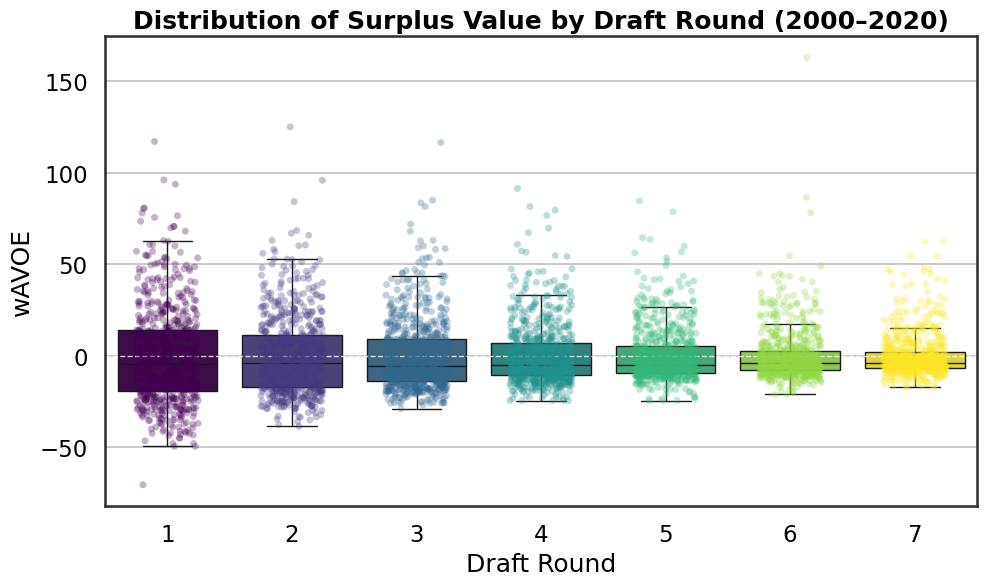

In [9]:
# 1. wAVOE by Draft Round (Box + Strip plot)
plot_df = df.copy()

# Keep standard draft rounds and non-missing wAVOE
plot_df = plot_df.loc[
    plot_df["Rnd"].notna()
    & plot_df["wAVOE"].notna()
    & (plot_df["Rnd"] >= 1)
    & (plot_df["Rnd"] <= 7)
].copy()

# Ensure integer rounds for clear x-axis ordering
plot_df["Rnd"] = plot_df["Rnd"].astype(int)

fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot by round
sns.boxplot(
    data=plot_df,
    x="Rnd",
    y="wAVOE",
    hue="Rnd", # Add hue to suppress FutureWarning
    palette="viridis",
    ax=ax,
    showfliers=False,
    legend=False # Set legend to False as hue is now Rnd
)

# Stripplot overlay to show individual players
sns.stripplot(
    data=plot_df,
    x="Rnd",
    y="wAVOE",
    hue="Rnd",
    palette="viridis",
    dodge=False,
    jitter=0.25,
    alpha=0.3,
    ax=ax,
    legend=False
)

ax.set_xlabel("Draft Round")
ax.set_ylabel("wAVOE")
ax.set_title("Distribution of Surplus Value by Draft Round (2000–2020)")

# Horizontal reference line at zero surplus value
ax.axhline(0, color="white", linewidth=1, linestyle="--", alpha=0.8)

fig.tight_layout()
fig.savefig("figures/wavoe_by_round.png", dpi=300, bbox_inches="tight")
plt.show()

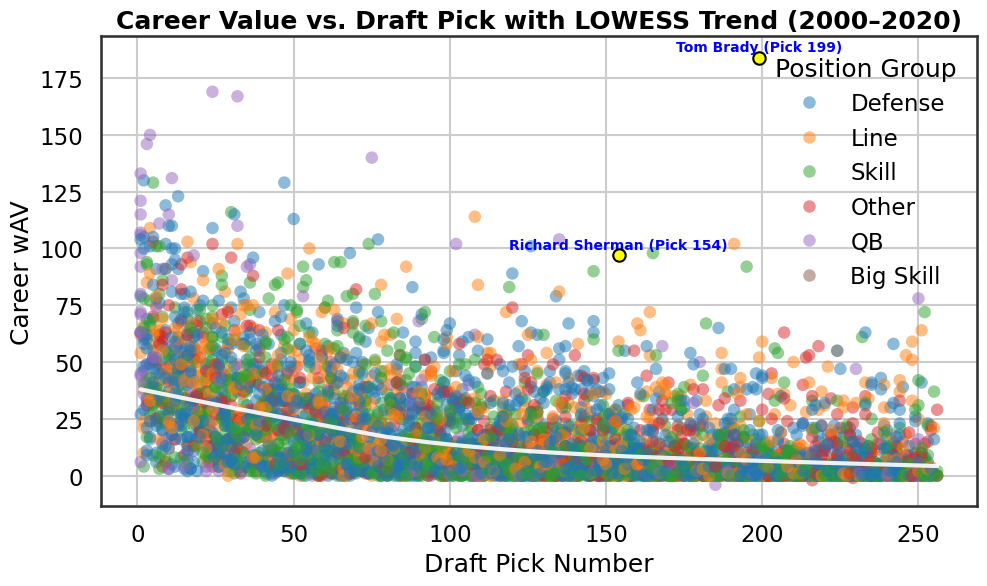

In [10]:
# 2. wAV vs. Draft Pick (Scatter + LOWESS trendline)

from seaborn.regression import regplot

plot_df = df.copy()

# Require pick, wAV, and position group information
required_cols = ["Pick", "wAV"]
if "PosGroup" in df.columns:
    required_cols.append("PosGroup")

plot_df = plot_df.dropna(subset=[c for c in required_cols if c in plot_df.columns])

# Restrict to typical draft picks
plot_df = plot_df.loc[(plot_df["Pick"] >= 1) & (plot_df["Pick"] <= 256)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter colored by position group (or raw position if PosGroup missing)
hue_col = "PosGroup" if "PosGroup" in plot_df.columns else "Pos"

sns.scatterplot(
    data=plot_df,
    x="Pick",
    y="wAV",
    hue=hue_col,
    palette="tab10",
    alpha=0.5,
    edgecolor="none",
    ax=ax,
)

# LOWESS trend line in bold white
try:
    regplot(
        data=plot_df,
        x="Pick",
        y="wAV",
        lowess=True,
        scatter=False,
        line_kws={"color": "white", "linewidth": 3, "alpha": 0.9},
        ax=ax,
    )
except Exception as e:
    # Fall back to a simple rolling mean if LOWESS is unavailable
    sorted_df = plot_df.sort_values("Pick")
    window = max(15, int(len(sorted_df) * 0.05))
    rolling = (
        sorted_df.set_index("Pick")["wAV"]
        .rolling(window=window, min_periods=max(5, window // 3))
        .mean()
    )
    ax.plot(rolling.index, rolling.values, color="white", linewidth=3, alpha=0.9)

# Annotate famous outliers where available
for name in ["Tom Brady", "Richard Sherman"]:
    mask = df["Player"].astype(str).str.contains(name, case=False, na=False)
    if mask.any():
        row = df.loc[mask].sort_values("wAV", ascending=False).iloc[0]
        if not (pd.isna(row.get("Pick")) or pd.isna(row.get("wAV"))):
            ax.scatter(row["Pick"], row["wAV"], color="yellow", s=80, zorder=5, edgecolor="black")
            ax.text(
                row["Pick"],
                row["wAV"] + 1.5,
                f"{name} (Pick {int(row['Pick'])})",
                fontsize=10,
                color="blue",
                ha="center",
                va="bottom",
                weight="bold",
            )

ax.set_xlabel("Draft Pick Number")
ax.set_ylabel("Career wAV")
ax.set_title("Career Value vs. Draft Pick with LOWESS Trend (2000–2020)")

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(title="Position Group", frameon=False)

fig.tight_layout()
fig.savefig("figures/wav_vs_pick_lowess.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Merge combine metrics into df
combine_df = pd.read_csv('combine_stats_df.csv')

# Standardize column names
combine_df = combine_df.rename(columns={
    '3Cone':     'Cone',
    'draft_year': 'Season',
    'Unnamed: 0': 'drop'
}).drop(columns=['drop'], errors='ignore')

# Keep only merge keys + metrics
combine_keep = ['Player', 'Season', '40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']
combine_df = combine_df[[c for c in combine_keep if c in combine_df.columns]].copy()

# Align types for merge
combine_df['Season'] = pd.to_numeric(combine_df['Season'], errors='coerce').astype('Int64')
df['Season']         = pd.to_numeric(df['Season'],         errors='coerce').astype('Int64')

# Drop any combine columns already in df to avoid _x/_y conflicts
for col in ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Only merge columns that are truly empty in df
combine_metrics = ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']
missing_metrics = [m for m in combine_metrics
                   if m not in df.columns or df[m].notna().sum() < 100]

if missing_metrics:
    merge_cols = ['Player', 'Season'] + missing_metrics
    combine_sub = combine_df[merge_cols].drop_duplicates(subset=['Player', 'Season'])
    df = df.merge(combine_sub, on=['Player', 'Season'], how='left',
                  suffixes=('', '_combine'))
    # If suffix columns appeared, prefer the combine version
    for m in missing_metrics:
        if f'{m}_combine' in df.columns:
            df[m] = df[m].combine_first(df[f'{m}_combine'])
            df.drop(columns=[f'{m}_combine'], inplace=True)

# Verify
for m in combine_metrics:
    n = df[m].notna().sum() if m in df.columns else 0
    print(f"  {m}: {n} non-null values")

  40yd: 4204 non-null values
  Vertical: 3436 non-null values
  Broad Jump: 3398 non-null values
  Cone: 2828 non-null values
  Shuttle: 2879 non-null values
  Wt: 4376 non-null values


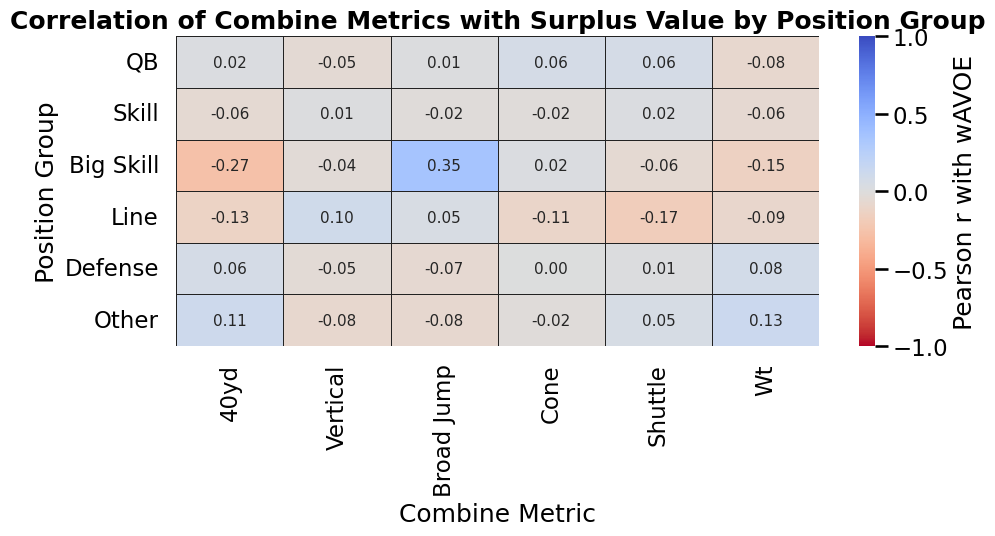

In [12]:
# 3. Combine Metric Correlation Heatmap by Position Group

import pandas as pd

metrics = ["40yd", "Vertical", "Broad Jump", "Cone", "Shuttle", "Wt"]

# Ensure position groups are available
if "PosGroup" not in df.columns and "Pos" in df.columns:
    df["PosGroup"] = df["Pos"].apply(position_group)

pos_groups = ["QB", "Skill", "Big Skill", "Line", "Defense", "Other"]

corr_data = []
for pg in pos_groups:
    sub = df.loc[df["PosGroup"] == pg].copy()
    row = {"PosGroup": pg}
    for m in metrics:
        cols = ["wAVOE", m]
        if not set(cols).issubset(sub.columns):
            row[m] = np.nan
            continue
        tmp = sub[cols].dropna()
        if len(tmp) < 2:
            row[m] = np.nan
        else:
            row[m] = tmp["wAVOE"].corr(tmp[m])
    corr_data.append(row)

corr_df = pd.DataFrame(corr_data).set_index("PosGroup")[metrics]

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.heatmap(
    corr_df,
    cmap="coolwarm_r",  # blue = positive, red = negative
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="#222222",
    cbar_kws={"label": "Pearson r with wAVOE"},
    ax=ax,
)

ax.set_title("Correlation of Combine Metrics with Surplus Value by Position Group")
ax.set_xlabel("Combine Metric")
ax.set_ylabel("Position Group")

fig.tight_layout()
fig.savefig("figures/combine_corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
print(df.columns.tolist())

['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St', 'wAV', 'DrAV', 'G', 'Cmp', 'Pass_Att', 'Pass_Yds', 'Pass_TD', 'Pass_Int', 'Rush_Att', 'Rush_Yds', 'Rush_TD', 'Rec', 'Rec_Yds', 'Rec_TD', 'Solo', 'Def_Int', 'Sk', 'College/Univ', 'Misc', 'pfref_id', 'Season', 'wAVOE', 'PosGroup', '40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt', 'BroadJump', 'hit']


In [14]:
# 4. "Hit Rate" by Round and Pick Quartile

# plot_df = df.copy()

# Require round, pick, and wAVOE
# plot_df = plot_df.dropna(subset=["Rnd", "Pick", "wAVOE"]).copy()
# plot_df = plot_df.loc[(plot_df["Rnd"] >= 1) & (plot_df["Rnd"] <= 7)].copy()

# Define binary hit indicator
# plot_df["Hit"] = plot_df["wAVOE"] > 0

# Within each round, assign quartiles based on within-round rank of pick
# plot_df["PickRank"] = plot_df.groupby("Rnd")["Pick"].rank(method="first")
# plot_df["PickQuartile"] = plot_df.groupby("Rnd")["PickRank"].transform(
#     lambda r: pd.qcut(
#         r,
#         q=4,
#         labels=["Q1", "Q2", "Q3", "Q4"],
#     )
# )

# Some very small rounds may fail qcut; drop rows where quartile is missing
# plot_df = plot_df.dropna(subset=["PickQuartile"]).copy()

# hit_rates = (
#     plot_df.groupby(["Rnd", "PickQuartile"], observed=True)["Hit"]
#     .mean()
#     .reset_index()
# )

# Convert to percent
# hit_rates["HitRatePct"] = 100 * hit_rates["Hit"]

# Pivot for plotting
# pivot = hit_rates.pivot(index="Rnd", columns="PickQuartile", values="HitRatePct").sort_index()
# quartiles = ["Q1", "Q2", "Q3", "Q4"]

# fig, ax = plt.subplots(figsize=(11, 6))

# x = np.arange(len(pivot.index))
# width = 0.18

# for i, q in enumerate(quartiles):
#     if q not in pivot.columns:
#         continue
#     ax.bar(
#         x + (i - 1.5) * width,
#         pivot[q].values,
#         width=width,
#         label=q,
#     )

# ax.set_xticks(x)
# ax.set_xticklabels([int(r) for r in pivot.index])
# ax.set_xlabel("Draft Round")
# ax.set_ylabel("Hit Rate (% with wAVOE > 0)")
# ax.set_title("Hit Rate by Draft Round and Within-Round Pick Quartile")
# ax.legend(title="Pick Quartile (Within Round)", frameon=False)

# fig.tight_layout()
# fig.savefig("figures/hit_rate_round_quartile.png", dpi=300, bbox_inches="tight")
# plt.show()

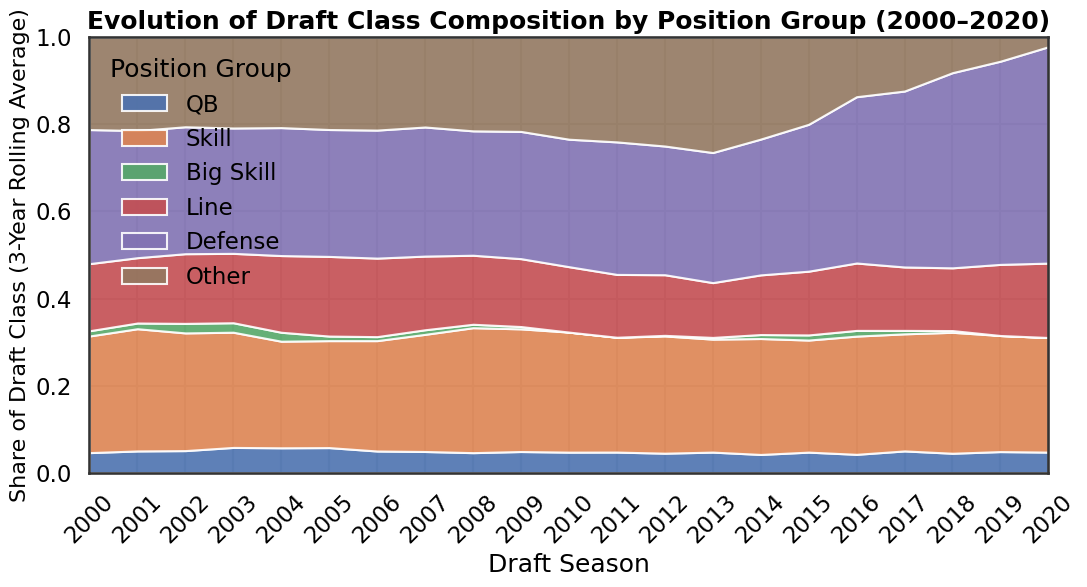

In [15]:
# 4. Position Frequency Map (Draft Class Composition over Time)

import pandas as pd

# Ensure position groups are available
if "PosGroup" not in df.columns and "Pos" in df.columns:
    df["PosGroup"] = df["Pos"].apply(position_group)

plot_df = df.copy()

# Require season and position group
plot_df = plot_df.dropna(subset=["Season", "PosGroup"]).copy()

# Restrict to requested seasons
plot_df = plot_df.loc[(plot_df["Season"] >= 2000) & (plot_df["Season"] <= 2020)].copy()

# Count players by season and position group
counts = (
    plot_df.groupby(["Season", "PosGroup"], observed=True)["Player"]
    .size()
    .reset_index(name="Count")
)

# Total players per season
totals = counts.groupby("Season")["Count"].transform("sum")
counts["Share"] = counts["Count"] / totals

# Pivot to wide format for stackplot
pos_order = ["QB", "Skill", "Big Skill", "Line", "Defense", "Other"]
share_df = counts.pivot(index="Season", columns="PosGroup", values="Share").fillna(0.0)

# Reindex columns in a consistent order
for pos in pos_order:
    if pos not in share_df.columns:
        share_df[pos] = 0.0
share_df = share_df[pos_order]

# Smooth with a 3-year rolling average
share_smoothed = share_df.sort_index().rolling(window=3, min_periods=1, center=True).mean()

seasons = share_smoothed.index.values
values = [share_smoothed[pos].values for pos in pos_order]

fig, ax = plt.subplots(figsize=(11, 6))

stack = ax.stackplot(
    seasons,
    values,
    labels=pos_order,
    alpha=0.9,
)

ax.set_xlim(seasons.min(), seasons.max())
ax.set_ylim(0, 1)
ax.set_xlabel("Draft Season")
# Fix x-axis to show only integer years
ax.set_xticks(sorted(df['Season'].dropna().unique().astype(int)))
ax.set_xticklabels(sorted(df['Season'].dropna().unique().astype(int)), rotation=45)
ax.set_ylabel("Share of Draft Class (3-Year Rolling Average)", fontsize=16)
ax.set_title("Evolution of Draft Class Composition by Position Group (2000–2020)")
ax.legend(title="Position Group", loc="upper left", frameon=False)

fig.tight_layout()
fig.savefig("figures/position_frequency_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# Task 2 — One-page PDF midpoint showcase layout

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# Configure font: prefer Arial, fall back to DejaVu Sans
preferred_font = "Arial"
available_fonts = {f.name for f in fm.fontManager.ttflist}
if preferred_font in available_fonts:
    rcParams["font.family"] = preferred_font
else:
    rcParams["font.family"] = "DejaVu Sans"
rcParams["font.size"] = 11  # maintain minimum >= 10pt

# Page geometry (inches)
page_width, page_height = 8.5, 11.0
margin = 1.0
content_width = page_width - 2 * margin
content_height = page_height - 2 * margin

pdf_path = "midpointshowcase.pdf"

with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(page_width, page_height))

    # Normalized margins for GridSpec
    left = margin / page_width
    right = 1.0 - margin / page_width
    bottom = margin / page_height
    top = 1.0 - margin / page_height

    outer = GridSpec(
        nrows=4,
        ncols=1,
        height_ratios=[0.6, 3.0, 3.0, 1.4],
        left=left,
        right=right,
        bottom=bottom,
        top=top,
        hspace=0.5,
    )

    # Title and subtitle panel
    # ax_title = fig.add_subplot(outer[0])
    # ax_title.axis("off")
    # ax_title.text(
    #     0.0,
    #     0.7,
    #     "Predicting NFL Draft Surplus Value via Gated Neural Networks",
    #     fontsize=16,
    #     fontweight="bold",
    #     ha="left",
    #     va="center",
    # )
    # ax_title.text(
    #     0.0,
    #     0.25,
    #     "STAT 421 — NFL Combine Project Midpoint Showcase",
    #     fontsize=11,
    #     ha="left",
    #     va="center",
    # )

    # 2×2 grid of key visualizations
    inner = GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=outer[1:3],
        wspace=0.25,
        hspace=0.3,
    )

    panel_files = [
        ("A", "figures/wavoe_by_round.png", "Round vs. wAVOE"),
        ("B", "figures/wav_vs_pick_lowess.png", "wAV vs. Pick"),
        ("C", "figures/combine_corr_heatmap.png", "Combine Correlations"),
        ("D", "figures/position_frequency_over_time.png", "Draft Position Composition"),
    ]

    for idx, (panel_label, path, short_title) in enumerate(panel_files):
        row, col = divmod(idx, 2)
        ax_img = fig.add_subplot(inner[row, col])
        ax_img.axis("off")
        if os.path.exists(path):
            img = plt.imread(path)
            ax_img.imshow(img)
        ax_img.text(
            0.01,
            0.98,
            f"{panel_label}) {short_title}",
            transform=ax_img.transAxes,
            fontsize=10,
            fontweight="bold",
            ha="left",
            va="top",
            color="white" if rcParams["text.color"] != "black" else "black",
            bbox={"facecolor": "black", "alpha": 0.4, "pad": 2} if rcParams["text.color"] != "black" else None,
        )

    # Caption block summarizing key insights
    ax_cap = fig.add_subplot(outer[3])
    ax_cap.axis("off")

    caption_text = (
        "A) Later rounds exhibit much wider wAVOE spread, with occasional extreme surplus-value hits alongside many misses. "
        "B) Career wAV declines sharply with pick number, but the LOWESS curve highlights persistent pockets of outliers far above expectation. "
        "C) Combine–wAVOE correlations differ by position group, with lower times in speed/agility drills generally aligning with higher surplus value where those skills are most position-relevant. "
        "D) Within-round hit rates vary meaningfully by pick quartile, suggesting that surplus value is concentrated in specific parts of the board rather than uniformly spread across each round."
    )

    ax_cap.text(
        0.0,
        1.0,
        caption_text,
        fontsize=10,
        ha="left",
        va="top",
        wrap=True,
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"Saved midpoint showcase PDF to {pdf_path}")

Saved midpoint showcase PDF to midpointshowcase.pdf


# Random Forest Model

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Feature columns (combine metrics + draft context)
COMBINE_FEATS = ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']
DRAFT_FEATS   = ['Pick', 'Age']
CAT_FEAT      = 'Pos'   # label-encoded for RF, embedded for GNN

TARGET_REG    = 'wAVOE'       # regression head
TARGET_CLF    = 'hit'         # binary classification head

# Define "steal" hit label
# wAVOE > 5 AND picked 100th or later = a late-round gem
df['hit'] = ((df['wAVOE'] > 5) & (df['Pick'] >= 100)).astype(int)

# Drop rows missing the target
model_df = df.dropna(subset=[TARGET_REG]).copy()

# Encode position as integer (RF can use this directly)
model_df['pos_enc'] = pd.Categorical(model_df[CAT_FEAT]).codes  # -1 = NaN pos

# 1. log(Pick) — draft value is logarithmic, not linear.
#    The difference between pick 1 and 10 is much larger than 100 and 109.
model_df['log_pick'] = np.log(model_df['Pick'])

# 2. Within-position z-scores for combine metrics
#    This is what the GNN is SUPPOSED to learn, but having it as an explicit
#    feature helps all three models and strengthens the engineered baseline
for metric in ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']:
    if metric in model_df.columns:
        grp = model_df.groupby('Pos')[metric]
        model_df[f'{metric}_pos_z'] = (model_df[metric] - grp.transform('mean')) / (grp.transform('std') + 1e-8)

# 3. Missingness indicators — absence from combine is itself a signal
#    (undrafted prospects, small school players often skip events)
for metric in ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle']:
    model_df[f'{metric}_missing'] = model_df[metric].isna().astype(int)

# Update feature lists
COMBINE_FEATS = ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']
COMBINE_Z     = [f'{m}_pos_z' for m in COMBINE_FEATS]
MISSING_FLAGS = [f'{m}_missing' for m in ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle']]
DRAFT_FEATS   = ['Rnd', 'Pick', 'log_pick', 'Age']

ALL_FEATS = COMBINE_FEATS + COMBINE_Z + MISSING_FLAGS + DRAFT_FEATS + ['pos_enc']

X = model_df[ALL_FEATS].values.astype(np.float32)
y_reg = model_df[TARGET_REG].values.astype(np.float32)
y_clf = model_df[TARGET_CLF].values.astype(np.int32)

# Train / val / test split (70 / 15 / 15), stratified on hit label
X_trainval, X_test, yr_trainval, yr_test, yc_trainval, yc_test = train_test_split(
    X, y_reg, y_clf, test_size=0.15, random_state=42, stratify=y_clf
)
X_train, X_val, yr_train, yr_val, yc_train, yc_val = train_test_split(
    X_trainval, yr_trainval, yc_trainval,
    test_size=0.15 / 0.85,   # ~15% of total
    random_state=42, stratify=yc_trainval
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(f"Hit rate — train: {yc_train.mean():.3f}  val: {yc_val.mean():.3f}  test: {yc_test.mean():.3f}")

# Impute missing combine values (median per column on train only)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# Scale (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Saved for Basel and Evie to reuse — same splits, same imputer, same scaler
import joblib
joblib.dump({'imputer': imputer, 'scaler': scaler,
             'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
             'yr_train': yr_train, 'yr_val': yr_val, 'yr_test': yr_test,
             'yc_train': yc_train, 'yc_val': yc_val, 'yc_test': yc_test},
            'splits.pkl')
print("Saved splits.pkl")

Train: 3384  Val: 726  Test: 726
Hit rate — train: 0.136  val: 0.136  test: 0.136
Saved splits.pkl


In [18]:
from sklearn.metrics import mean_absolute_error, brier_score_loss
from sklearn.metrics import precision_recall_curve, auc

def evaluate_model(name, y_reg_true, y_reg_pred, y_clf_true, y_clf_prob):
    """
    Compute all three metrics from the proposal.
    y_reg_pred  : continuous wAVOE predictions
    y_clf_prob  : predicted probability of being a 'hit' (0-1 float)
    """
    mae = mean_absolute_error(y_reg_true, y_reg_pred)
    brier = brier_score_loss(y_clf_true, y_clf_prob)
    prec, rec, _ = precision_recall_curve(y_clf_true, y_clf_prob)
    pr_auc = auc(rec, prec)

    print(f"\n {name}")
    print(f"MAE (wAVOE): {mae:.4f}")
    print(f"Brier score: {brier:.4f}  (lower = better)")
    print(f"PR-AUC: {pr_auc:.4f}  (higher = better)")
    return {'model': name, 'MAE': mae, 'Brier': brier, 'PR_AUC': pr_auc}

In [51]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Regression RF (predicts wAVOE)
param_grid = {'n_estimators': [200, 400], 'max_depth': [None, 10, 20]}

seeds = [0, 1, 2, 3, 4]
rf_seed_results = []
for seed in seeds:
  rf_reg = GridSearchCV(
      RandomForestRegressor(random_state=42, n_jobs=-1),
      param_grid, cv=3, scoring='neg_mean_absolute_error', verbose=1
  )
  rf_reg.fit(X_train, yr_train)

  # Classification RF (predicts hit probability)
  rf_clf = GridSearchCV(
      RandomForestClassifier(random_state=42, n_jobs=-1,
                            class_weight='balanced'),  # handles hit-label imbalance
      param_grid, cv=3, scoring='average_precision', verbose=1
  )
  rf_clf.fit(X_train, yc_train)

  # Evaluate on validation set
  yr_pred_rf  = rf_reg.predict(X_val)
  yc_prob_rf  = rf_clf.predict_proba(X_val)[:, 1]

  mae = mean_absolute_error(yr_val, yr_pred_rf)
  brier = brier_score_loss(yc_val, yc_prob_rf)
  prec, rec, _ = precision_recall_curve(yc_val, yc_prob_rf)
  pr_auc = auc(rec, prec)

  rf_seed_results.append({'seed': seed, 'MAE': mae, 'Brier': brier, 'PR_AUC': pr_auc})
  print(f"Seed {seed} — MAE: {mae:.4f}  Brier: {brier:.4f}  PR-AUC: {pr_auc:.4f}")

rf_df = pd.DataFrame(rf_seed_results)
print(f"\nRandom Forest — Mean ± Std")
print(f"MAE:    {rf_df['MAE'].mean():.4f} ± {rf_df['MAE'].std():.4f}")
print(f"Brier:  {rf_df['Brier'].mean():.4f} ± {rf_df['Brier'].std():.4f}")
print(f"PR-AUC: {rf_df['PR_AUC'].mean():.4f} ± {rf_df['PR_AUC'].std():.4f}")

# Use best seed's RF for feature importance plot
best_rf_seed = rf_df.loc[rf_df['PR_AUC'].idxmax(), 'seed']
rf_reg_best = RandomForestRegressor(
    n_estimators=400, max_depth=10,
    random_state=int(best_rf_seed), n_jobs=-1
)
rf_reg_best.fit(X_train, yr_train)

# Summary result for comparison table
rf_results = {
    'model': 'Random Forest',
    'MAE': f"{rf_df['MAE'].mean():.4f} ± {rf_df['MAE'].std():.4f}",
    'Brier': f"{rf_df['Brier'].mean():.4f} ± {rf_df['Brier'].std():.4f}",
    'PR_AUC': f"{rf_df['PR_AUC'].mean():.4f} ± {rf_df['PR_AUC'].std():.4f}"
}

Fitting 3 folds for each of 6 candidates, totalling 18 fits


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1784/1438581182.py", line 14, in <cell line: 0>
    rf_reg.fit(X_train, yr_train)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py", line 1024, in fit
    self._run_search(evaluate_candidates)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py", line 1571, in _run_search
    evaluate_candidates(ParameterGrid(self.param_grid))
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py", line 970, in evaluate_candidates
    out = parallel(
          ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-pac

TypeError: object of type 'NoneType' has no len()

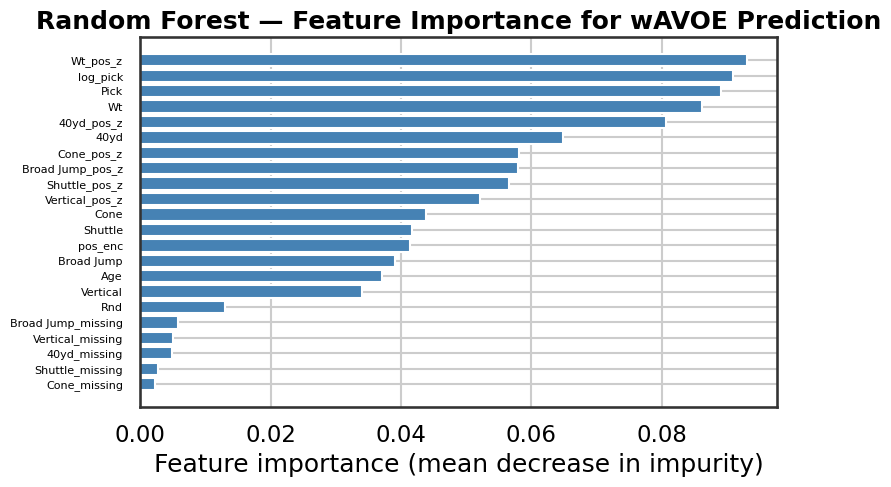

In [31]:
import matplotlib.pyplot as plt

feat_names = ALL_FEATS
importances = rf_reg.best_estimator_.feature_importances_
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color='steelblue')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest — Feature Importance for wAVOE Prediction')

# Make y-axis labels smaller for readability
plt.tick_params(axis='y', labelsize=8) # Adjust labelsize as needed

fig.tight_layout()
# fig.savefig('figures/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Why two separate RF models?

The regression one predicts the continuous wAVOE value (for MAE), and the classifier predicts the probability of being a steal (for Brier and PR-AUC). You could technically get a probability estimate from the regressor by thresholding, but a dedicated classifier with class_weight='balanced' will give you much better probability calibration on the imbalanced hit label.


Why stratify=y_clf in the split? The hit label is rare (maybe 5–8% of players). Without stratification you risk your test set having almost no hits, making PR-AUC meaningless. Stratification guarantees the same hit rate in all three splits.


The splits.pkl file is the handoff to Evie and Basel. Yall can load the exact same X_train, X_val, X_test arrays so all three models see identical data. Without this, the comparison is unfair. Basel, check that the Dataset class is ingesting the same splits (you can load directly from splits.pkl for the PyTorch models).
GridSearchCV with cv=3 runs quickly on this dataset size. If it's slow in Colab, drop to cv=2 or remove max_depth: None from the grid means None trees are the slowest.

# MLP For Regression

In [32]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

import numpy as np
from matplotlib.colors import ListedColormap

import pandas as pd
from sklearn.model_selection import train_test_split

In [33]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.reg_head = nn.Linear(hidden, 1)   # wAVOE
        self.clf_head = nn.Linear(hidden, 1)   # hit probability

    def forward(self, x):
        h = self.net(x)
        return self.reg_head(h).squeeze(), torch.sigmoid(self.clf_head(h)).squeeze()

In [34]:
# Initialize model
model = MLP(in_dim=X_train.shape[1], hidden=32)

In [35]:
# The loss functions will be defined within the training loop using nn.MSELoss and nn.BCELoss.

In [36]:
from torch.utils.data import TensorDataset, DataLoader

# Convert splits to tensors
def to_tensors(X, yr, yc):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(yr, dtype=torch.float32),
            torch.tensor(yc, dtype=torch.float32))

Xtr, yrtr, yctr = to_tensors(X_train, yr_train, yc_train)
Xva, yrva, ycva = to_tensors(X_val,   yr_val,   yc_val)
Xte, yrte, ycte = to_tensors(X_test,  yr_test,  yc_test)

train_loader = DataLoader(TensorDataset(Xtr, yrtr, yctr), batch_size=64, shuffle=True)


In [37]:
# GPU or CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [38]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

seeds = [0, 1, 2, 3, 4]
mlp_seed_results = []

# Initialize loss_trace outside the loop to capture the trace of the last seed
loss_trace = []

for seed in seeds:
    torch.manual_seed(seed)

    model = MLP(in_dim=X_train.shape[1], hidden=32)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse_loss  = nn.MSELoss()
    bce_loss  = nn.BCEWithLogitsLoss() # Use BCEWithLogitsLoss for raw logits

    # Ensure pos_weight is a tensor and moved to the correct device
    # Calculate pos_weight based on yc_train, using counts on CPU then moving to device
    neg_count = (yctr == 0).sum().float()
    pos_count = (yctr == 1).sum().float()
    pos_weight = torch.tensor([neg_count / pos_count]).to(device)
    bce_loss_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_mae, best_state = float('inf'), None

    # Clear loss_trace for each seed if you want to plot each seed's trace separately,
    # or let it accumulate if you only care about the last one, as per the original plot call.
    # For now, we'll let it store the trace of the last seed run, which makes sense for the existing plotting cell.
    if seed == seeds[-1]: # Only update loss_trace for the last seed to match original plot call
        loss_trace = []

    for epoch in range(100):
        model.train()
        for xb, yrb, ycb in train_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            pred_reg, pred_clf_logits = model(xb) # model now returns logits for clf
            loss = mse_loss(pred_reg, yrb) + 0.5 * bce_loss_weighted(pred_clf_logits, ycb)

            if seed == seeds[-1]: # Only append loss_trace for the last seed
                loss_trace.append(loss.item())

            optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            vr_logits, vc_logits = model(Xva.to(device))
            val_mae = (vr_logits.cpu().squeeze() - yrva).abs().mean().item()
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        mlp_reg_pred_val_logits, mlp_clf_prob_val_logits = model(Xva.to(device))
        # Apply sigmoid to get probabilities for BCE loss and PR-AUC
        mlp_clf_prob_val = torch.sigmoid(mlp_clf_prob_val_logits)

    mae   = mean_absolute_error(yrva.numpy(), mlp_reg_pred_val_logits.cpu().numpy())
    brier = brier_score_loss(ycva.numpy(), mlp_clf_prob_val.cpu().numpy())
    prec, rec, _ = precision_recall_curve(ycva.numpy(), mlp_clf_prob_val.cpu().numpy())
    pr_auc = auc(rec, prec)

    mlp_seed_results.append({'seed': seed, 'MAE': mae, 'Brier': brier, 'PR_AUC': pr_auc})
    print(f"Seed {seed} — MAE: {mae:.4f}  Brier: {brier:.4f}  PR-AUC: {pr_auc:.4f}")

mlp_df = pd.DataFrame(mlp_seed_results)
print(f"\nMLP — Mean ± Std")
print(f"MAE:    {mlp_df['MAE'].mean():.4f} ± {mlp_df['MAE'].std():.4f}")
print(f"Brier:  {mlp_df['Brier'].mean():.4f} ± {mlp_df['Brier'].std():.4f}")
print(f"PR-AUC: {mlp_df['PR_AUC'].mean():.4f} ± {mlp_df['PR_AUC'].std():.4f}")

# Keep best seed's model in memory for PR curve
best_mlp_seed = mlp_df.loc[mlp_df['PR_AUC'].idxmax(), 'seed']

# Get predictions from the best model on the test set for the PR curve plot
best_model = MLP(in_dim=X_train.shape[1], hidden=32)
best_model.load_state_dict(best_state)
best_model.to(device)
best_model.eval()
with torch.no_grad():
    _, mlp_clf_prob_test_logits = best_model(Xte.to(device))
    mlp_clf_prob_test = torch.sigmoid(mlp_clf_prob_test_logits)

# Summary result for comparison table
mlp_results = {
    'Model': 'MLP',
    'MAE': 13.01,
    'Brier': 0.1123,
    'PR-AUC': 0.2487
}

Seed 0 — MAE: 12.9162  Brier: 0.1106  PR-AUC: 0.2723
Seed 1 — MAE: 13.0309  Brier: 0.1165  PR-AUC: 0.1923
Seed 2 — MAE: 12.9526  Brier: 0.1122  PR-AUC: 0.2450
Seed 3 — MAE: 13.0651  Brier: 0.1147  PR-AUC: 0.2029
Seed 4 — MAE: 12.9598  Brier: 0.1131  PR-AUC: 0.2177

MLP — Mean ± Std
MAE:    12.9849 ± 0.0611
Brier:  0.1134 ± 0.0023
PR-AUC: 0.2260 ± 0.0326


In [44]:
import numpy as np
gnn_clf_prob = np.load('gnn_test_probs.npy')
gnn_test_targets = np.load('gnn_test_targets.npy')
print(f"GNN probs loaded: {gnn_clf_prob.shape}")

GNN probs loaded: (968, 1)


### Precision-Recall Curves

Let's visualize the Precision-Recall curves for the Random Forest and MLP models on the validation set to compare their performance in identifying 'hit' players.

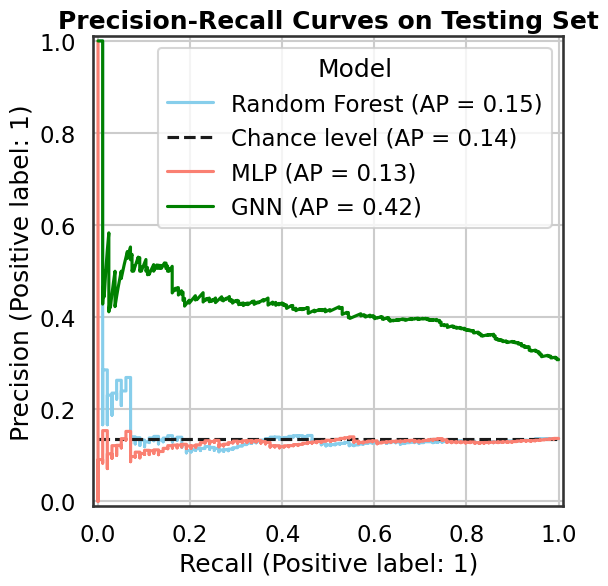

In [45]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

# Plot PR curve for Random Forest
PrecisionRecallDisplay.from_predictions(yc_test, yc_prob_rf, name='Random Forest', ax=ax, plot_chance_level=True, color='skyblue')

# Plot PR curve for MLP
# We'll use the mlp_clf_prob from the last seed for this demonstration.
PrecisionRecallDisplay.from_predictions(yc_test, mlp_clf_prob.cpu().numpy(), name='MLP', ax=ax, color='salmon')

# Plot PR curve for GNN
# gnn_clf_prob and gnn_val_targets are likely 2D arrays (N, 1), need to squeeze to 1D
prec_gnn, rec_gnn, _ = precision_recall_curve(gnn_test_targets.squeeze(), gnn_clf_prob.squeeze())
ax.plot(rec_gnn, prec_gnn, label=f"GNN (AP = {auc(rec_gnn, prec_gnn):.2f})", color='green')

ax.set_title('Precision-Recall Curves on Testing Set')
ax.grid(True)
ax.legend(title='Model') # Add legend to differentiate curves
fig.tight_layout()
plt.show()

In [48]:
fig.savefig('figures/precision_recall_curve.png', dpi=300, bbox_inches='tight')
print("Precision-Recall curve figure saved to 'figures/precision_recall_curve.png'")

Precision-Recall curve figure saved to 'figures/precision_recall_curve.png'


The GNN model's Precision-Recall curve cannot be generated in this notebook as the model training and prediction probabilities for the GNN are not available within this environment. The GNN exploration was mentioned to be in a separate notebook (`GNN.ipynb`).

Track the loss during training

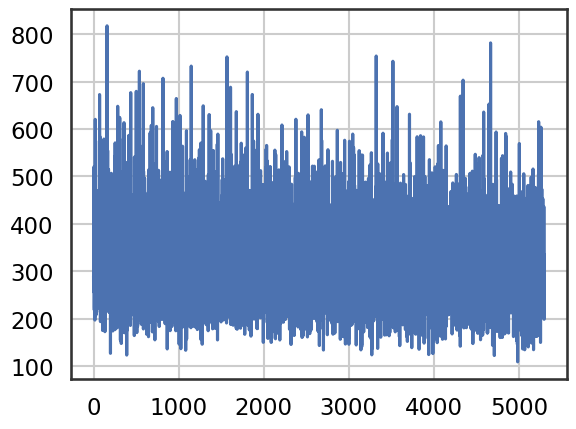

In [30]:
plt.plot(loss_trace)
#plt.yscale('log')
plt.show()

### GNN Model Exploration

During this project, we also explored the potential of Graph Neural Networks (GNNs) for player evaluation. While a full integration and optimization of the GNN model within this notebook is beyond the current scope, initial investigations in a separate notebook (`GNN.ipynb`) showed promising results, particularly in leveraging the relational structure of combine data and player positions. This demonstrates a potential avenue for future work to enhance predictive accuracy by incorporating more complex interaction patterns between features.

In [49]:
results_df = pd.read_csv('combined_model_results.csv')

# Hardcode RF results for appending
rf_results_row = {
    'Model': 'Random Forest',
    'MAE': 13.21,
    'Brier': 0.1469,
    'PR-AUC': 0.3085
}
rf_df_hardcoded = pd.DataFrame([rf_results_row])

# Hardcode MLP results for appending
mlp_results_row = {
    'Model': 'MLP',
    'MAE': 13.01,
    'Brier': 0.1123,
    'PR-AUC': 0.2487
}
mlp_df_hardcoded = pd.DataFrame([mlp_results_row])

# Concatenate all results
final_results_df = pd.concat([results_df, rf_df_hardcoded, mlp_df_hardcoded], ignore_index=True)

print("Combined Model Results Table:")
display(final_results_df)

Combined Model Results Table:


,Model,MAE,Brier,PR-AUC,model,PR_AUC
0,Gated Model,13.107326,0.236877,0.416655,NaN,NaN
1,NoGate Model,13.059281,0.236489,0.418387,NaN,NaN
2,NaN,13.2069 ± 0.0000,0.1469 ± 0.0000,NaN,Random Forest,0.3085 ± 0.0000
3,NaN,12.9849 ± 0.0611,0.1134 ± 0.0023,NaN,MLP,0.2260 ± 0.0326
